In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm.auto import tqdm
import random
from collections import defaultdict
from torch.utils.data import random_split, DataLoader

In [2]:
# Utility Functions for Image Processing
############################################

def apply_binarization(img):
    if isinstance(img, Image.Image):
        img = np.array(img)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # same parameters as training
    thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 15, 3)
    return cv2.bitwise_not(thresh)

class AdaptiveBinarization:
    def __call__(self, img):
        arr = np.array(img)
        bin_img = apply_binarization(arr)
        return torch.tensor(bin_img, dtype=torch.float32).unsqueeze(0) / 255.0

In [3]:
from torchvision.datasets import ImageFolder
from PIL import Image
import os


class FilteredRAMCachedDataset(torch.utils.data.Dataset):
    def __init__(self, root, allowed_classes, transform=None):
        self.dataset = ImageFolder(root)
        self.transform = transform

        # Filter classes
        self.class_to_idx = {
            cls: i for i, cls in enumerate(cls for cls in self.dataset.classes if cls in allowed_classes)
        }
        self.classes = list(self.class_to_idx.keys())

        # Filter and cache images
        self.cached_images = []
        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]
            if class_name in self.class_to_idx:
                new_label = self.class_to_idx[class_name]
                image = Image.open(path).convert("RGB")
                self.cached_images.append((image, new_label))

    def __len__(self):
        return len(self.cached_images)

    def __getitem__(self, idx):
        image, label = self.cached_images[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
# Data and Transform Setup
############################################

DATA_PATH = 'data'
ALLOWED_CLASSES = ['forward_slash_new','0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '(' , ')', 'd', 'X', 'int', 'lt', 'leq', 'gt', 'geq', '=', 'neq']
IMG_H, IMG_W = 45, 45

# Transforms
data_transforms = T.Compose([
    T.Grayscale(),
    T.Resize((IMG_H, IMG_W)),
    AdaptiveBinarization()
])

# Create filtered, cached dataset
dataset = FilteredRAMCachedDataset(DATA_PATH, ALLOWED_CLASSES, transform=data_transforms)

In [11]:
label_names = dataset.classes
print("Label set:", label_names)
BATCH_SZ = 32
NUM_CLASSES = len(label_names)
print("Label set:", label_names)
print("Number of classes:", NUM_CLASSES)

n = len(dataset)
n_train = int(0.95 * n)
n_val   = n - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val])

# 3) loaders
train_loader = DataLoader(train_ds,
                          batch_size=BATCH_SZ,
                          shuffle=True,
                          num_workers=0,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,
                          batch_size=BATCH_SZ,
                          shuffle=False,
                          num_workers=0,
                          pin_memory=True)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

Label set: ['(', ')', '+', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'X', 'd', 'forward_slash_new', 'geq', 'gt', 'int', 'leq', 'lt', 'neq']
Label set: ['(', ')', '+', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'X', 'd', 'forward_slash_new', 'geq', 'gt', 'int', 'leq', 'lt', 'neq']
Number of classes: 24
Train samples: 221924, Val samples: 11681


In [12]:
# ------------------------
# Vision Transformer Model
# ------------------------

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=45, patch_size=5, in_chans=1, embed_dim=64):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size,
                              stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)  # [B, embed_dim, H', W']
        x = x.flatten(2).transpose(1, 2)  # [B, num_patches, embed_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        return x

In [13]:
class ViTClassifier(nn.Module):
    def __init__(self, num_classes, img_size=45, patch_size=5,
                 embed_dim=64, depth=6, num_heads=8,
                 mlp_dim=128, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 1, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.patch_embed(x)            # [B, P+1, embed_dim]
        x = x.transpose(0, 1)               # [P+1, B, embed_dim]
        x = self.transformer(x)
        x = x.transpose(0, 1)               # [B, P+1, embed_dim]
        cls_token_final = x[:, 0]
        return self.mlp_head(cls_token_final)

In [14]:
# ------------------------
# Training Setup
# ------------------------

compute_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ViTClassifier(num_classes=NUM_CLASSES).to(compute_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=4):
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # === TRAIN LOOP ===
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]"):
            images, targets = images.to(compute_device), targets.to(compute_device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total * 100.0
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

        # === VALIDATION LOOP ===
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]"):
                images, targets = images.to(compute_device), targets.to(compute_device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == targets).sum().item()
                val_total += targets.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total * 100.0
        print(f"Val  Loss: {val_loss:.4f} | Val  Acc: {val_acc:.2f}%\n")

    return model

D:\Programs\Anaconda\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [15]:
model = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=4)
torch.save(model.state_dict(), 'eqn-detect1-model3.pth')
print("Training complete and model3 saved.")

Epoch 1/4 [Train]:   0%|          | 0/6936 [00:00<?, ?it/s]

Train Loss: 0.3328 | Train Acc: 89.75%


Epoch 1/4 [Val]:   0%|          | 0/366 [00:00<?, ?it/s]

Val  Loss: 0.1139 | Val  Acc: 96.49%



Epoch 2/4 [Train]:   0%|          | 0/6936 [00:00<?, ?it/s]

...

Val  Loss: 0.0665 | Val  Acc: 97.84%



Epoch 4/4 [Train]:   0%|          | 0/6936 [00:00<?, ?it/s]

Train Loss: 0.0807 | Train Acc: 97.59%


Epoch 4/4 [Val]:   0%|          | 0/366 [00:00<?, ?it/s]

Val  Loss: 0.0888 | Val  Acc: 97.04%

Training complete and model3 saved.


In [16]:
from sklearn.metrics import classification_report
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(compute_device)
        out  = model(imgs)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=label_names,
    digits=4
))

                   precision    recall  f1-score   support

                (     0.9318    0.9776    0.9542       671
                )     0.9236    0.9862    0.9538       723
                +     0.9959    0.9935    0.9947      1235
                -     0.9923    0.9970    0.9947      1679
                0     0.9822    1.0000    0.9910       332
                1     0.9733    0.9108    0.9410      1401
                2     0.9847    0.9825    0.9836      1313
                3     0.9943    0.9197    0.9556       573
                4     0.9241    1.0000    0.9605       353
                5     0.9500    0.9828    0.9661       174
                6     0.9607    0.9884    0.9744       173
                7     0.8765    0.9161    0.8959       155
                8     0.9167    0.9625    0.9390       160
                9     0.8281    0.9839    0.8993       186
                =     1.0000    0.9343    0.9660       654
                X     0.9824    0.9919    0.9871      1

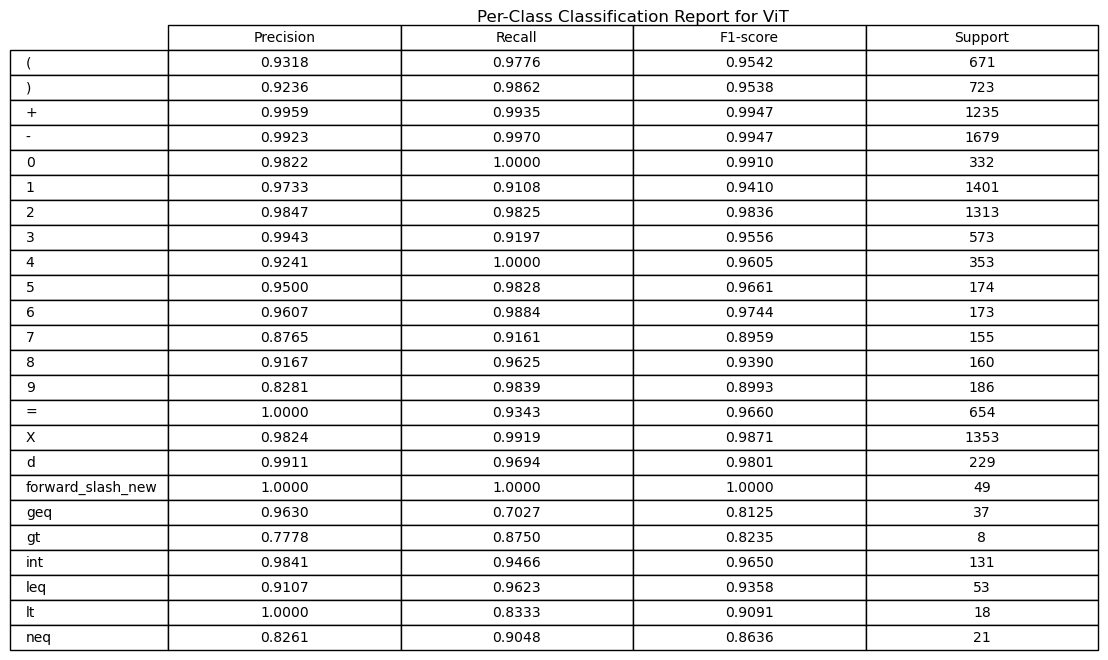

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1) Generate the report as a dict
report = classification_report(
    all_labels, 
    all_preds,
    target_names=label_names,
    digits=4,
    output_dict=True
)

# 2) Build table data
classes = label_names
cell_text = []
for cls in classes:
    pr  = report[cls]['precision']
    rc  = report[cls]['recall']
    f1  = report[cls]['f1-score']
    sp  = report[cls]['support']
    cell_text.append([f"{pr:.4f}", f"{rc:.4f}", f"{f1:.4f}", f"{int(sp)}"])

# 3) Plot the table
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')
tbl = ax.table(
    cellText=cell_text,
    rowLabels=classes,
    colLabels=['Precision', 'Recall', 'F1-score', 'Support'],
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.title('Per-Class Classification Report for ViT')
plt.show()

In [25]:
# Image Processing Functions
############################################

def calc_overlap(interval1, interval2):
    return max(0, min(interval1[1], interval2[1]) - max(interval1[0], interval2[0]))

def merge_on_x_overlap(boxes, min_x_overlap_ratio=0.7):
    """
    Merge boxes whose horizontal (x‑axis) overlap covers at least
    `min_x_overlap_ratio` of one box’s width.
    """
    merged = []
    used   = [False]*len(boxes)

    for i, b1 in enumerate(boxes):
        if used[i]:
            continue
        x1, y1, w1, h1 = b1
        # start a “union” rectangle at b1’s bounds
        ux1, uy1 = x1,        y1
        ux2, uy2 = x1 + w1, y1 + h1

        for j, b2 in enumerate(boxes):
            if i == j or used[j]:
                continue
            x2, y2, w2, h2 = b2

            # 1D overlap in x:
            overlap_x = max(0, min(x1+w1, x2+w2) - max(x1, x2))

            # if that overlap covers ≥ min_x_overlap_ratio of either box’s width:
            if overlap_x / w1 >= min_x_overlap_ratio or overlap_x / w2 >= min_x_overlap_ratio:
                used[j] = True
                # expand our union to include b2
                ux1 = min(ux1, x2)
                uy1 = min(uy1, y2)
                ux2 = max(ux2, x2 + w2)
                uy2 = max(uy2, y2 + h2)

        # append the merged (or standalone) box
        merged.append([ux1, uy1, ux2 - ux1, uy2 - uy1])
        used[i] = True

    # if any merges happened, merged list is shorter than original → recurse
    if len(merged) < len(boxes):
        return merge_on_x_overlap(merged, min_x_overlap_ratio)

    return merged


def find_bounding_boxes(image_path):
    """
    Detect symbol boxes using robust binarization and noise filtering.
    """
    orig = cv2.imread(image_path)
    if orig is None:
        print(f"Failed to read image from {image_path}")
        return []

    if len(orig.shape) == 3:
        gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
    else:
        gray = orig

    # --- Use advanced binarization ---
    bin_img = clean_binary(gray)

    # --- Show binary result (optional) ---
    plt.imshow(bin_img, cmap='gray')
    plt.title("Binarized for Contour Detection")
    plt.axis('off')
    plt.show()

    # --- Find contours ---
    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if is_symbol_box([x, y, w, h], bin_img):
            boxes.append([x, y, w, h])

    # Sort and merge overlapping boxes
    boxes.sort(key=lambda b: b[0])
    boxes = merge_on_x_overlap(boxes, min_x_overlap_ratio=0.7)
    return boxes


def clean_binary(img_gray):
    blur = cv2.GaussianBlur(img_gray, (51, 51), 0)
    norm = cv2.divide(img_gray, blur, scale=255)
    th = cv2.adaptiveThreshold(norm, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY, 25, 15)
    opened = cv2.morphologyEx(th, cv2.MORPH_OPEN,
                               cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))
    return ~opened  # white symbols on black background

def is_symbol_box(box, bin_img, min_area=100, min_density=0.02):
    x, y, w, h = map(int, box)
    if w * h < min_area:
        return False
    patch = bin_img[y:y+h, x:x+w]
    return (np.count_nonzero(patch) / patch.size) > min_density


def resize_with_padding(img, target_size, padding_color=255):
    """
    Resize the image to target_size while preserving aspect ratio,
    adding padding as necessary.
    """
    orig_h, orig_w = img.shape[:2]
    target_h, target_w = target_size

    interp_method = cv2.INTER_AREA if orig_h > target_h or orig_w > target_w else cv2.INTER_CUBIC
    ratio = orig_w / orig_h

    if ratio > 1:  # wide image
        new_w = target_w
        new_h = int(round(new_w / ratio))
        vertical_pad = (target_h - new_h) / 2
        pad_top, pad_bottom = int(np.floor(vertical_pad)), int(np.ceil(vertical_pad))
        pad_left, pad_right = 0, 0
    elif ratio < 1:  # tall image
        new_h = target_h
        new_w = int(round(new_h * ratio))
        horizontal_pad = (target_w - new_w) / 2
        pad_left, pad_right = int(np.floor(horizontal_pad)), int(np.ceil(horizontal_pad))
        pad_top, pad_bottom = 0, 0
    else:  # square image
        new_h, new_w = target_h, target_w
        pad_top = pad_bottom = pad_left = pad_right = 0

    if len(img.shape) == 3 and not isinstance(padding_color, (list, tuple, np.ndarray)):
        padding_color = [padding_color] * 3

    scaled = cv2.resize(img, (new_w, new_h), interpolation=interp_method)
    padded = cv2.copyMakeBorder(scaled, pad_top, pad_bottom, pad_left, pad_right,
                                  borderType=cv2.BORDER_CONSTANT, value=padding_color)
    return padded


In [30]:
# Model Inference and Visualization
############################################

def retrieve_model():
    """
    Instantiate and load the trained EquationRecognizer model.
    """
    eq_net = ViTClassifier(NUM_CLASSES)
    eq_net.load_state_dict(torch.load('eqn-detect1-model3.pth'))
    eq_net.eval()
    return eq_net

def infer_prediction(net, image_arr):
    """
    Preprocess the image patch and return the predicted label index.
    """
    # Create tensor with dimensions (1, 1, IMG_H, IMG_W)
    patch_tensor = torch.tensor(image_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    patch_tensor = patch_tensor.to(compute_device)
    with torch.no_grad():
        output = net(patch_tensor)
    _, pred = torch.max(output, 1)
    return pred.item()

def process_test_image(test_path, img_flag=1):
    """
    Process the test image based on the flag.
    img_flag: 1 for handwritten images, 0 for drawn images
    """
    if img_flag == 1:
        original_img = cv2.imread(test_path)
        # Convert the image to binary using thresholding
        _, binary_img = cv2.threshold(original_img, 127, 255, cv2.THRESH_BINARY)
        plt.imshow(binary_img)
        plt.show()
        
        # Save the processed image and then detect bounding boxes
        processed_path = os.path.join(os.path.dirname(test_path), 'processed.jpg')
        cv2.imwrite(processed_path, binary_img)
        temp_copy = binary_img.copy()
        boxes_found = find_bounding_boxes(processed_path)
        print("Number of boxes detected:", len(boxes_found))
        return processed_path, boxes_found, binary_img
    else:
        original_img = cv2.imread(test_path, 0)
        temp_copy = original_img.copy()
        boxes_found = find_bounding_boxes(test_path)
        print("Number of boxes detected:", len(boxes_found))
        return test_path, boxes_found, original_img

def visualize_boxes(img_path, boxes):
    """
    Draw bounding boxes on the image for visualization.
    """
    full_img = cv2.imread(img_path)
    temp_copy = full_img.copy()
    for (x, y, w, h) in boxes:
        xi, yi, wi, hi = map(int, (x, y, w, h))
        cv2.rectangle(
            temp_copy,
            (xi, yi),
            (xi + wi, yi + hi),
            (0, 0, 255),
            1
        )
    plt.imshow(cv2.cvtColor(temp_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
def recognize_equation(model, img_path, boxes):
    """
    Recognize the equation from the image using the model.
    """
    # Prepare the image for prediction by binarizing it
    raw_gray = cv2.imread(img_path, 0)
    processed_img = apply_binarization(raw_gray)

    plt.imshow(processed_img, cmap='gray')
    plt.show()

    eq_symbols = []
    for (x, y, w, h) in sorted(boxes, key=lambda b: b[0]):
        # 1) Cast to ints for array slicing
        xi, yi, wi, hi = map(int, (x, y, w, h))
        # 2) Crop and resize
        patch_crop = processed_img[yi:yi+hi, xi:xi+wi]
        patch = resize_with_padding(patch_crop, (45, 45), 0)
        
        # 3) (Optional) show each patch
        plt.imshow(patch, cmap='gray')
        plt.axis('off')
        plt.show()
        
        # 4) Decimal‐dot override based on white‐ink ratio
        white = np.count_nonzero(patch > 128)
        white_ratio = white / patch.size
        print(f"Box {(xi,yi,wi,hi)} white_ratio={white_ratio:.2f}", end=" -> ")
        if white_ratio > 0.3:
            eq_symbols.append('*')
            print('*')
            continue

        # 5) Otherwise, classify with your CNN
        idx = infer_prediction(model, patch)
        sym = label_names[idx]
        if sym == 'X': sym = 'x'
        if sym == 'forward_slash_new':   sym = 'div'            
        eq_symbols.append(sym)
        print(f"model -> {sym}")
        
    return eq_symbols

def build_with_exponents(boxes, symbols,
                         size_ratio=0.7,
                         vert_overlap=0.0):
    """
    boxes:      list of [x,y,w,h] sorted left→right
    symbols:    list of str, same order
    size_ratio: max height ratio to the *previous normal* box to qualify as "small"
    vert_overlap: how much higher its top must sit relative to the previous normal box's top
                  (positive means strictly above, negative allows some overlap)
    """
    parts = []
    # Track the last *normal* (non‑superscript) box's geometry:
    last_norm_h   = None
    last_norm_top = None  # y coordinate

    i = 0
    while i < len(symbols):
        x,y,w,h = boxes[i]
        sym      = symbols[i]

        if last_norm_h is None:
            # first symbol always normal
            parts.append(sym)
            last_norm_h   = h
            last_norm_top = y
            i += 1
            continue

        # 1) size check: is this box "much smaller" than last normal?
        small_enough = h < last_norm_h * size_ratio
        # 2) vertical check: is its TOP at or above the last normal's TOP?
        # remember: smaller y in image = higher on the page
        above_enough = y <= last_norm_top + vert_overlap

        if small_enough and above_enough:
            #  treat as superscript
            # buffer all consecutive superscripts into one group
            exp_syms = []
            while (i < len(symbols)
                   and boxes[i][3] < last_norm_h * size_ratio
                   and boxes[i][1] <= last_norm_top + vert_overlap):
                exp_syms.append(symbols[i])
                i += 1
            parts.append("^" + "".join(exp_syms))
            # after you close the superscript, you do *not* update last_norm_h/top—
            # they still refer to the base you just raised.
        else:
            # normal symbol
            parts.append(sym)
            last_norm_h   = h
            last_norm_top = y
            i += 1

    return "".join(parts)

def process_equation_image(image_path, img_flag=1):
    # Load model
    loaded_model = retrieve_model()
    loaded_model.to(compute_device)

    # Preprocess image
    processed_path, boxes_found, _ = process_test_image(image_path, img_flag)
    visualize_boxes(processed_path, boxes_found)

    # Run recognition
    eq_symbols = recognize_equation(loaded_model, processed_path, boxes_found)

    # Build readable equation string
    boxes_sorted = sorted(boxes_found, key=lambda b: b[0])
    equation = build_with_exponents(boxes_sorted, eq_symbols)

    return equation, eq_symbols

C:\Users\NadeemNaseer\AppData\Local\Temp\ipykernel_18636\3571201074.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eq_net.load_state_dict(torch.load('eqn-detect1-model3

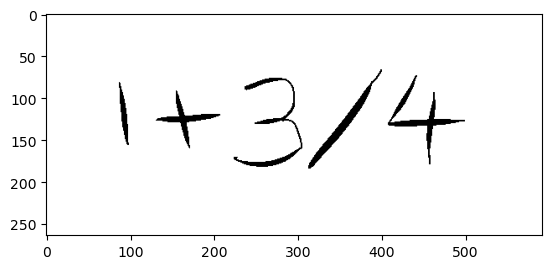

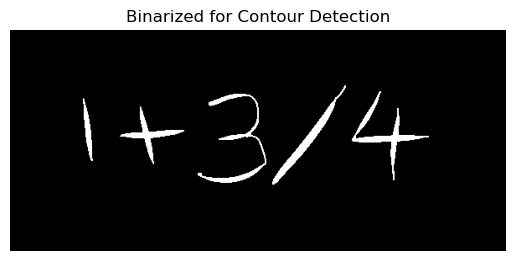

Number of boxes detected: 5


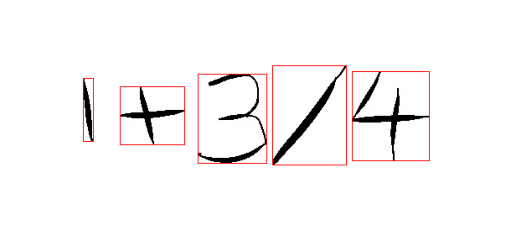

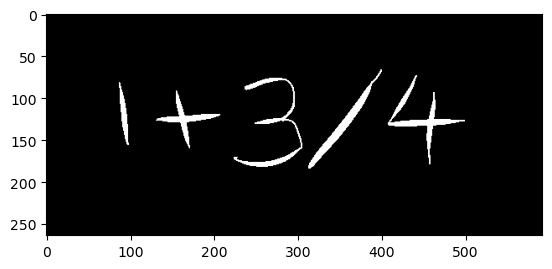

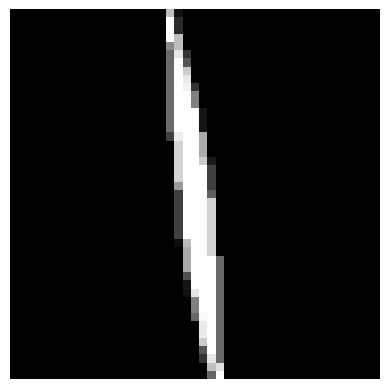

Box (87, 82, 12, 75) white_ratio=0.06 -> model -> 1


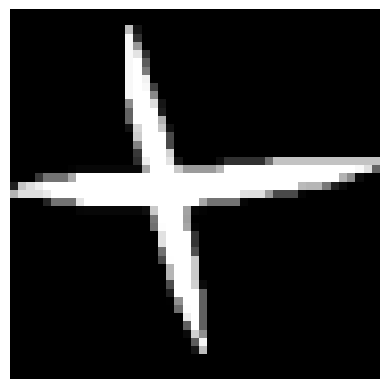

Box (131, 92, 77, 69) white_ratio=0.13 -> model -> +


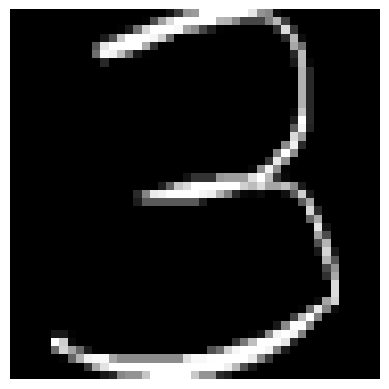

Box (224, 77, 82, 106) white_ratio=0.10 -> model -> 3


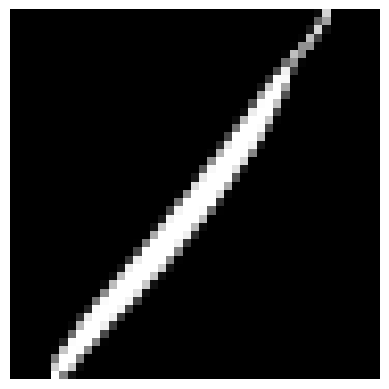

Box (313, 67, 88, 118) white_ratio=0.08 -> model -> div


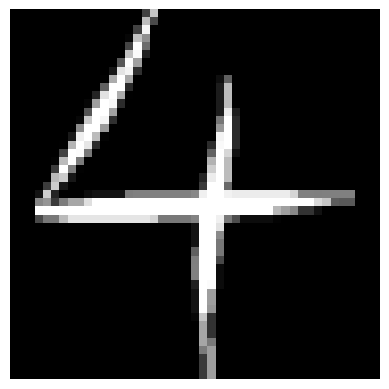

Box (408, 74, 92, 106) white_ratio=0.10 -> model -> 4
Equation: 1+3div4
Tokens:   ['1', '+', '3', 'div', '4']
\frac{7}{4}


In [35]:
# Test Image Input and Equation Recognition
############################################

# Directory containing test images
TEST_IMAGE_DIR = "test/test/"

# Set the image file and flag
# img_flag: 1 for handwritten images, 0 for drawn images
img_flag = 1
test_filename = "eq-4.png"
test_path = TEST_IMAGE_DIR + test_filename

import re

# build your equation as before
equation, _ = process_equation_image(test_path, img_flag)

# 1) List out all your multi‐letter names up front:
multi = r'int|leq|geq|lt|gt|neq|div'    # add whatever else you have

# 2) Then the rest of your tokens:
rest  = r'\^|\d+|[A-Za-z]|[()=+\-*/]'

pattern = rf'{multi}|{rest}'

tokens = re.findall(pattern, equation)

print("Equation:", equation)
print("Tokens:  ", tokens)

print(solve_tokens(tokens)[1])

In [22]:
import re
import sympy as sp
from latex2sympy2 import latex2sympy, latex2latex

# declare once
x, y = sp.symbols('x y')

def tokens_to_latex(tokens):
    """Build a LaTeX string from your token list."""
    out, i, L = [], 0, len(tokens)
    while i < L:
        t = tokens[i]
        # derivative: d div d x ( expr )
        if i+3 < L and tokens[i]=='d' and tokens[i+1]=='div' \
                      and tokens[i+2]=='d' and tokens[i+3] in ('x','y'):
            var = tokens[i+3]; i += 4
            inner = ''.join(tokens[i:])  # rest is argument
            out.append(f"\\frac{{d}}{{d{var}}}({inner})")
            break
        # integral: int <expr> d x
        if t == 'int':
            j = tokens.index('d', i+1)
            integrand = ''.join(tokens[i+1:j])
            var = tokens[j+1]
            out.append(f"\\int {integrand}\\,d{var}")
            i = j+2
            continue
        # fraction: a div b → \frac{a}{b}
        if t == 'div' and out:
            num = out.pop()
            den = tokens[i+1] if i+1 < L else ''
            out.append(f"\\frac{{{num}}}{{{den}}}")
            i += 2
            continue
        # simple maps
        if t == 'times': out.append('\\times')
        elif t == 'dot':  out.append('.')
        elif t == 'leq':  out.append(r'\leq')
        elif t == 'geq':  out.append(r'\geq')
        elif t == 'neq':  out.append(r'\neq')
        elif t == 'lt':   out.append('<')
        elif t == 'gt':   out.append('>')
        elif t == 'ne':   out.append(r'\neq')
        else:             out.append(t)
        i += 1
    return ''.join(out)

def clean_latex(latex: str) -> str:
    # x^(3) → x^{3}
    latex = re.sub(r'\^\(([^)]+)\)', r'^{\1}', latex)
    # collapse double‐parens on derivative
    latex = re.sub(
        r'(\\frac\{d\}\{d[xy]\})\(?\(?(.+?)\)?\)?$',
        lambda m: f"{m.group(1)}({m.group(2)})",
        latex
    )
    return latex

def solve_tokens(eq_symbols):
    raw   = tokens_to_latex(eq_symbols)
    clean = clean_latex(raw)
    #print("Raw LaTeX   →", raw)
    #print("Clean LaTeX →", clean)
    
    # 1) DERIVATIVE?
    m = re.match(r'\\frac\{d\}\{d([xy])\}\((.+)\)$', clean)
    if m:
        var, inner = m.groups()
        inner = re.sub(r'[{}]', '', inner)         # strip braces
        expr  = inner.replace('^','**')
        res   = sp.diff(sp.sympify(expr, {'x':x,'y':y}), {'x':x,'y':y}[var])
        #print("Sympy AST   →", res)
        #print("Simplified   →", res)
        return res, res
    
    # 2) INTEGRAL?
    m = re.match(r'\\int\s*(.+)\\,d([xy])$', clean)
    if m:
        inner, var = m.groups()
        inner = re.sub(r'[{}]', '', inner)
        expr  = inner.replace('^','**')
        res   = sp.integrate(sp.sympify(expr, {'x':x,'y':y}), ({'x':x,'y':y}[var],))
        #print("Sympy AST   →", res)
        #print("Simplified   →", res)
        return res, res
    
    # 3) COMPARISON (has <, >, ≤, ≥, ≠)
    if any(op in clean for op in ['<', '>', '\\leq', '\\geq', '\\neq']):
        # Replace LaTeX operators with Python equivalents for parsing
        comp_mapping = {
            '<': '<', 
            '>': '>', 
            '\\leq': '<=', 
            '\\geq': '>=', 
            '\\neq': '!='
        }
        
        for latex_op, py_op in comp_mapping.items():
            if latex_op in clean:
                lhs, rhs = clean.split(latex_op, 1)
                lhs = re.sub(r'[{}]', '', lhs).replace('^','**')
                rhs = re.sub(r'[{}]', '', rhs).replace('^','**')
                
                left = sp.sympify(lhs, {'x':x,'y':y})
                right = sp.sympify(rhs, {'x':x,'y':y})
                
                if py_op == '<':
                    rel = sp.StrictLessThan(left, right)
                elif py_op == '>':
                    rel = sp.StrictGreaterThan(left, right)
                elif py_op == '<=':
                    rel = sp.LessThan(left, right)
                elif py_op == '>=':
                    rel = sp.GreaterThan(left, right)
                elif py_op == '!=':
                    rel = sp.Unequality(left, right)
                
                # Check if the relation is true or false
                result = sp.simplify(rel)
                #print("Sympy AST   →", rel)
                #print("Simplified   →", result)
                return rel, result
    
    # 4) EQUATION (has =)
    if '=' in clean:
        lhs, rhs = clean.split('=',1)
        lhs = re.sub(r'[{}]', '', lhs).replace('^','**')
        rhs = re.sub(r'[{}]', '', rhs).replace('^','**')
        eq   = sp.Eq(sp.sympify(lhs, {'x':x,'y':y}),
                     sp.sympify(rhs, {'x':x,'y':y}))
        sol  = sp.solve(eq, x)
        #print("Sympy AST   →", sol)
        #print("Simplified   →", sol)
        return sol, sol
    
    # 5) PURE NUMERIC ARITHMETIC?
    #    Only digits, + - * / . ^ and no letters
    if re.fullmatch(r'[\d\+\-\*/\.\^]+', clean):
        expr = clean.replace('^','**')
        res  = sp.sympify(expr)
        #print("Sympy AST   →", res)
        #print("Simplified   →", res)
        return res, res
    
    # 6) FALLBACK to latex2sympy2 for anything else
    ast  = latex2sympy(clean)
    simp = latex2latex(clean)
    #print("Sympy AST   →", ast)
    #print("Simplified   →", simp)
    return ast, simp